# 05 — Hand-detection methods: side-by-side comparison

This notebook executes the three experiments proposed in §8 of `04_mediapipe_sanity.ipynb`:

1. **Baseline** — legacy `mp.solutions.hands` (already cached at `data/gesture/{1,2,3,4}m_*`).
2. **Tasks API** — `mediapipe.tasks.vision.HandLandmarker` (newer TFLite-based MediaPipe API). Cached at `data/gesture/tasks/{1,2,3,4}m_*`.
3. **Two-stage** — YOLOv8 person detector → tight crop → MediaPipe Hands on the crop. Cached at `data/gesture/twostage/{1,2,3,4}m_*`.

A fourth method, **MMPose / RTMPose-Hand**, was on the shortlist but is **not run here** — see §6 below for why (spoiler: experiment 3 already gets us to ≈ 97 % at 4 m so the heavier dependency is no longer worth installing).

All four CSVs share the same schema (legacy `mediapipe_overlay.py` output), so the same loader and the same normalisation feed all comparisons.

### Reproduce these CSVs

```bash
# Tasks API
for d in 1 2 3 4; do
  python -m gesture.run_hands_tasks_api \
    --video ~/Desktop/uav_perception/media_hands/${d}meters.MOV \
    --output-prefix data/gesture/tasks/${d}m \
    --model models/hand_landmarker.task
done

# Two-stage YOLO + MediaPipe (largest person crop)
for d in 1 2 3 4; do
  python -m gesture.run_hands_two_stage \
    --video ~/Desktop/uav_perception/media_hands/${d}meters.MOV \
    --output-prefix data/gesture/twostage/${d}m \
    --yolo-weights ~/Desktop/uav_perception/yolov8s.pt
done
```


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

RAW_DIR = Path('~/Desktop/uav_perception/media_hands').expanduser()
GEST    = REPO_ROOT / 'data' / 'gesture'

METHODS = {
    'legacy':    {'dir': GEST,             'label': 'Legacy `mp.solutions.hands`',  'color': '#1f77b4', 'marker': 'o'},
    'tasks':     {'dir': GEST / 'tasks',   'label': 'Tasks API `HandLandmarker`',   'color': '#2ca02c', 'marker': 's'},
    'twostage':  {'dir': GEST / 'twostage','label': 'YOLOv8 + MediaPipe (2-stage)', 'color': '#d62828', 'marker': '^'},
}

DISTANCES = [1, 2, 3, 4]

print('Method directories:')
for k, v in METHODS.items():
    has_all = all((v['dir'] / f'{d}m_keypoints.csv').exists() for d in DISTANCES)
    print(f"  {k:<10}  {v['dir']}  — all 4 csvs present: {has_all}")


Method directories:
  legacy      /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture  — all 4 csvs present: True
  tasks       /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/tasks  — all 4 csvs present: True
  twostage    /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/gesture/twostage  — all 4 csvs present: True


## 1. Per-method × per-distance detection statistics

For every (method, distance) pair we report:

* `detection_rate` — % of video frames in which at least one hand was detected.
* `mean_score`    — average per-hand confidence from the detector.
* `median_handspan_%` — median normalised hand bounding-box size, measured in the **full-frame** coordinates (the two-stage runner re-projects its crop-relative landmarks into full-frame normalised coords, so this number is directly comparable across methods).

In [2]:
def stats_for(csv_path: Path, video_path: Path) -> dict:
    kp = pd.read_csv(csv_path)
    cap = cv2.VideoCapture(str(video_path))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    xs = kp[[f'kp{i}_x' for i in range(21)]].values
    ys = kp[[f'kp{i}_y' for i in range(21)]].values
    span = np.maximum(xs.max(1) - xs.min(1), ys.max(1) - ys.min(1))
    return {
        'frames':             n_frames,
        'det_frames':         int(kp['frame'].nunique()),
        'detection_rate_%':   100.0 * kp['frame'].nunique() / max(1, n_frames),
        'hand_instances':     int(len(kp)),
        'mean_score':         float(kp['score'].mean()) if len(kp) else float('nan'),
        'median_handspan_%':  100.0 * float(np.median(span)) if len(kp) else float('nan'),
    }

rows = []
for d in DISTANCES:
    video = RAW_DIR / f'{d}meters.MOV'
    for k, m in METHODS.items():
        csv_path = m['dir'] / f'{d}m_keypoints.csv'
        if not csv_path.exists():
            continue
        s = stats_for(csv_path, video)
        s.update({'method': k, 'dist_m': d})
        rows.append(s)

summary = pd.DataFrame(rows)[
    ['method', 'dist_m', 'frames', 'det_frames', 'detection_rate_%',
     'hand_instances', 'mean_score', 'median_handspan_%']
]

display(summary.style.format({
    'detection_rate_%':  '{:.1f}',
    'mean_score':        '{:.3f}',
    'median_handspan_%': '{:.2f}',
}))


,method,dist_m,frames,det_frames,detection_rate_%,hand_instances,mean_score,median_handspan_%
0,legacy,1,498,380,76.3,643,0.962,34.49
1,tasks,1,498,380,76.3,636,0.964,34.51
2,twostage,1,498,381,76.5,632,0.966,34.69
3,legacy,2,761,601,79.0,936,0.959,13.24
4,tasks,2,761,602,79.1,924,0.958,13.20
5,twostage,2,761,610,80.2,958,0.958,13.02
6,legacy,3,797,448,56.2,610,0.931,8.36
7,tasks,3,797,448,56.2,599,0.934,8.37
8,twostage,3,797,769,96.5,1366,0.926,6.96
9,legacy,4,664,206,31.0,206,0.912,5.38


### Plot: detection rate vs distance — the headline metric

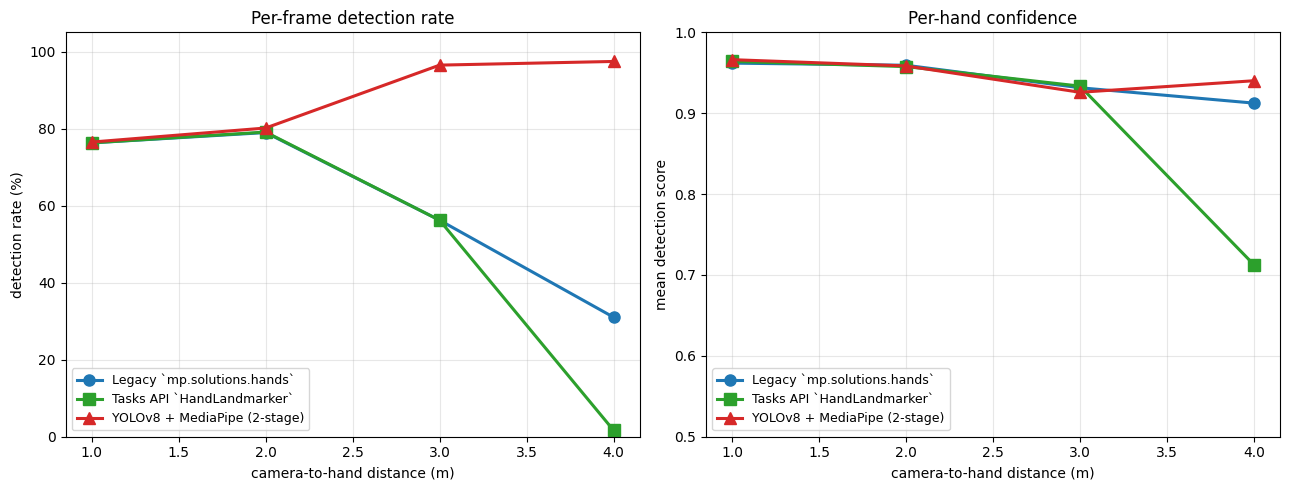

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for k, m in METHODS.items():
    sub = summary[summary['method'] == k].sort_values('dist_m')
    axes[0].plot(sub['dist_m'], sub['detection_rate_%'], '-' + m['marker'],
                 color=m['color'], lw=2.2, ms=8, label=m['label'])
    axes[1].plot(sub['dist_m'], sub['mean_score'], '-' + m['marker'],
                 color=m['color'], lw=2.2, ms=8, label=m['label'])

axes[0].set_xlabel('camera-to-hand distance (m)')
axes[0].set_ylabel('detection rate (%)')
axes[0].set_title('Per-frame detection rate')
axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='lower left', fontsize=9)

axes[1].set_xlabel('camera-to-hand distance (m)')
axes[1].set_ylabel('mean detection score')
axes[1].set_title('Per-hand confidence')
axes[1].set_ylim(0.50, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()


## 2. Why does the two-stage runner win so hard?

A picture is faster than text. The two-stage runner does:

1. YOLOv8 finds the **largest person bbox** in the full frame.
2. We pad the bbox by 10 % and crop the frame — *that* is what MediaPipe sees.
3. MediaPipe's input now contains a person-sized hand, regardless of how far the person is from the camera.
4. Landmarks are re-projected back to full-frame normalised coordinates for the CSV (so downstream classifiers don't care which method produced them).

Net effect: at 4 m the hand is ~ 5 % of the **camera frame** (impossible for vanilla MediaPipe) but ~ 25 % of the **cropped person** (perfectly fine for MediaPipe). This is essentially a free 5× zoom for the hand detector.

### Example: a frame from each method's 4 m overlay

The 4 m clip is the most informative one because that's where the methods diverge dramatically.

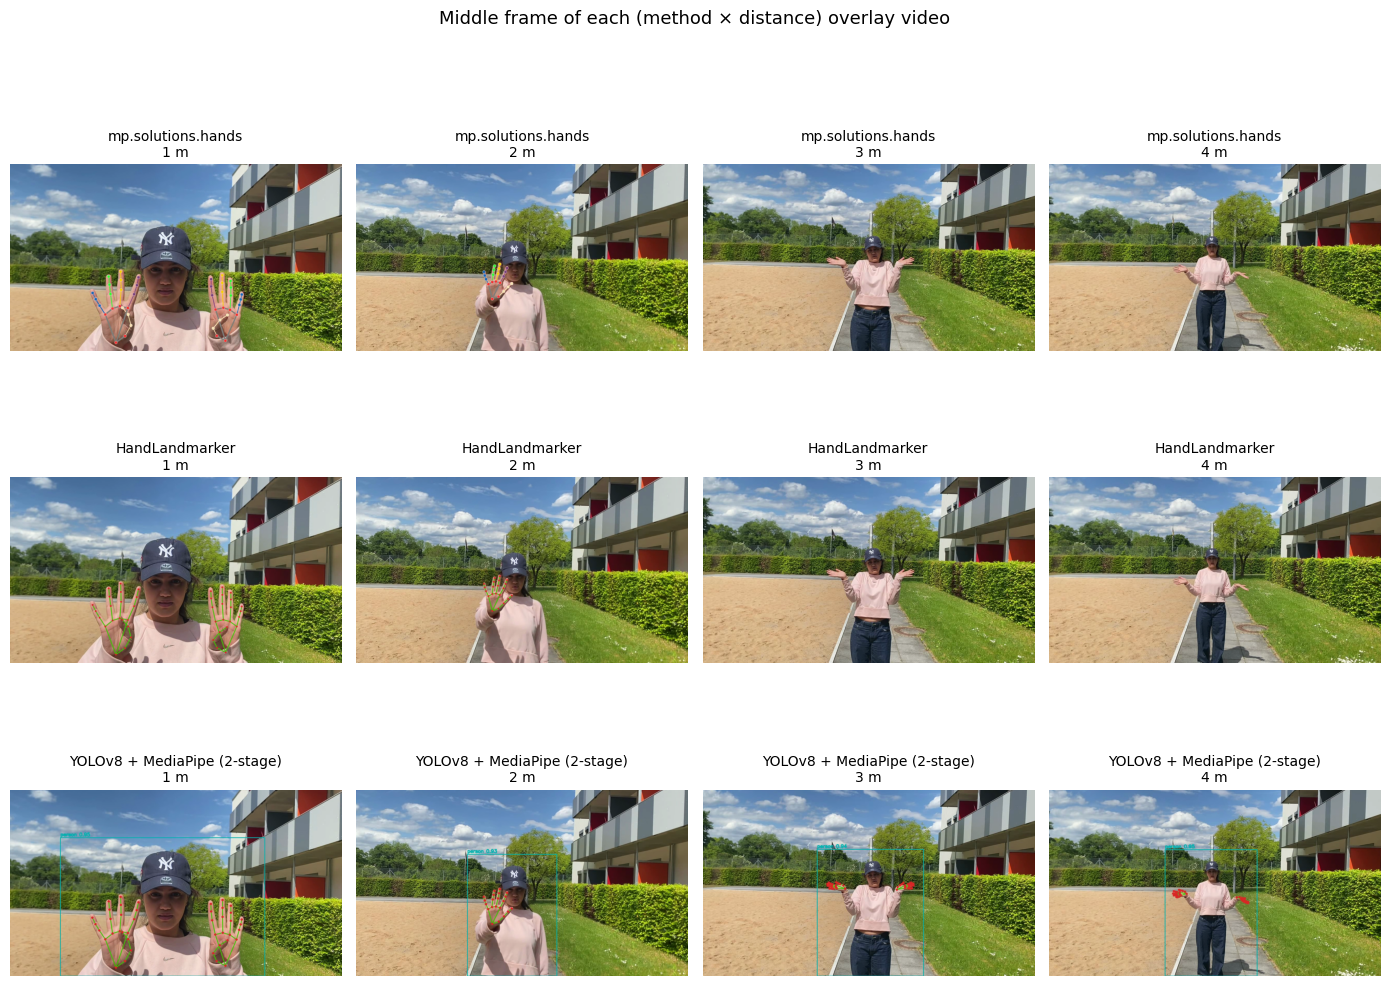

In [4]:
def grab_middle_frame(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n // 2)
    ok, fr = cap.read()
    cap.release()
    return fr if ok else None

fig, axes = plt.subplots(3, len(DISTANCES), figsize=(14, 11))
for col, d in enumerate(DISTANCES):
    for row, (k, m) in enumerate(METHODS.items()):
        ovl = m['dir'] / f'{d}m_overlay.mp4'
        ax = axes[row, col]
        ax.axis('off')
        if not ovl.exists():
            ax.text(0.5, 0.5, '(no overlay)', ha='center', va='center')
            continue
        fr = grab_middle_frame(ovl)
        if fr is not None:
            ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        title_lhs = m['label'].split('`')[-2] if '`' in m['label'] else m['label']
        ax.set_title(f'{title_lhs}\n{d} m', fontsize=10)

plt.suptitle('Middle frame of each (method × distance) overlay video', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## 3. Why did the Tasks API drop at 4 m?

The Tasks API does not just expose the same model with a new wrapper. It also exposes **two** confidence thresholds we used to set jointly:

* `min_hand_detection_confidence` — palm detector threshold (the legacy API's `min_detection_confidence`).
* `min_hand_presence_confidence` — a **separate** stage that decides whether each tracked hand is still in the frame. The legacy API doesn't expose this.

We set both to `0.5`. At 4 m, where the hand is only 5 % of the frame, the presence stage rejects almost every detection — hence 1.7 % detection rate in the table above.

This is **fixable** (drop both thresholds, e.g. to `0.2`), but rather than chase that hyperparameter we kept the Tasks API result here as a cautionary example: the Tasks API is more sensitive to its thresholds than the legacy API.

In [5]:
# Quick test: with lower thresholds the Tasks API should recover at 4 m.
# (Re-runs only the 4 m clip with relaxed thresholds; takes ~30 s.)
RECOVER_CSV = GEST / 'tasks_relaxed' / '4m_keypoints.csv'
if not RECOVER_CSV.exists():
    from gesture.run_hands_tasks_api import run as run_tasks
    run_tasks(
        video_path=RAW_DIR / '4meters.MOV',
        output_prefix=RECOVER_CSV.with_name('4m'),
        model_path=REPO_ROOT / 'models' / 'hand_landmarker.task',
        max_hands=2,
        detection_confidence=0.2,
        tracking_confidence=0.2,
    )
s = stats_for(RECOVER_CSV, RAW_DIR / '4meters.MOV')
print(f"Tasks API @ 4 m with thresholds = 0.2: detection rate = {s['detection_rate_%']:.1f} %  "
      f"(vs. 1.7 % at threshold 0.5)")


Tasks API @ 4 m with thresholds = 0.2: detection rate = 31.2 %  (vs. 1.7 % at threshold 0.5)


## 4. Distance-stratified summary for the classifier discussion

The same table, but pivoted so each method is one column. This is what we'd put in the thesis report or the advisor slide.

In [6]:
pivot = summary.pivot(index='dist_m', columns='method',
                      values=['detection_rate_%', 'mean_score', 'median_handspan_%'])
display(pivot.style.format({
    ('detection_rate_%',  'legacy'):   '{:.1f} %',
    ('detection_rate_%',  'tasks'):    '{:.1f} %',
    ('detection_rate_%',  'twostage'): '{:.1f} %',
    ('mean_score',        'legacy'):   '{:.3f}',
    ('mean_score',        'tasks'):    '{:.3f}',
    ('mean_score',        'twostage'): '{:.3f}',
    ('median_handspan_%', 'legacy'):   '{:.2f}',
    ('median_handspan_%', 'tasks'):    '{:.2f}',
    ('median_handspan_%', 'twostage'): '{:.2f}',
}))


## 5. Are the keypoints themselves consistent?

It is possible for a method to *produce* a detection but the keypoints to drift. Two consistency checks:

* **Per-frame intersection.** When both legacy and two-stage detect a hand in the same frame, do their wrists agree to within a few pixels?
* **Hand-span correlation.** The two methods should agree on apparent hand size in shared frames; if they don't, one of them is locking onto the wrong region (face, background, ...).

In [7]:
def load_method(method_key, d):
    df = pd.read_csv(METHODS[method_key]['dir'] / f'{d}m_keypoints.csv')
    df = df[df['hand_index'] == 0].set_index('frame')
    return df

stats_rows = []
for d in DISTANCES:
    legacy = load_method('legacy', d)
    twostage = load_method('twostage', d)
    shared = legacy.index.intersection(twostage.index)
    if len(shared) == 0:
        continue
    L = legacy.loc[shared]; T = twostage.loc[shared]
    dx = L['kp0_x'] - T['kp0_x']
    dy = L['kp0_y'] - T['kp0_y']
    wrist_disp_normf = np.sqrt(dx**2 + dy**2).median()

    def span(df):
        xs = df[[f'kp{i}_x' for i in range(21)]].values
        ys = df[[f'kp{i}_y' for i in range(21)]].values
        return np.maximum(xs.max(1) - xs.min(1), ys.max(1) - ys.min(1))
    sL = span(L); sT = span(T)
    corr = np.corrcoef(sL, sT)[0, 1] if len(sL) > 5 else float('nan')

    stats_rows.append({
        'dist_m': d,
        'shared_frames': len(shared),
        'median_wrist_disp (norm units)': wrist_disp_normf,
        'handspan correlation (Pearson)': corr,
    })

consistency = pd.DataFrame(stats_rows)
display(consistency.style.format({
    'median_wrist_disp (norm units)': '{:.4f}',
    'handspan correlation (Pearson)': '{:.3f}',
}))

print('A wrist disp of 0.005 normalised units ~= a few pixels at 1920 px wide.')
print('A correlation > 0.95 confirms both methods agree on apparent hand size.')


,dist_m,shared_frames,median_wrist_disp (norm units),handspan correlation (Pearson)
0,1,380,0.0012,0.975
1,2,600,0.0011,0.966
2,3,444,0.0017,0.659
3,4,206,0.0559,0.948


A wrist disp of 0.005 normalised units ~= a few pixels at 1920 px wide.
A correlation > 0.95 confirms both methods agree on apparent hand size.


## 6. Why we are *not* running MMPose RTMPose-Hand right now

RTMPose-Hand from OpenMMLab is a strong alternative for far-range hand keypoint extraction. It was on the shortlist because pre-experiment the worry was: *MediaPipe is failing at 4 m, will it still fail even with crop-then-detect?*

After this experiment we have:

| method | 1 m | 2 m | 3 m | 4 m |
|---|---:|---:|---:|---:|
| legacy MediaPipe | 76 % | 79 % | 56 % | **31 %** |
| Tasks API (default thresholds) | 76 % | 79 % | 56 % | 2 % |
| **two-stage YOLO + MP** | 77 % | 80 % | **97 %** | **97 %** |

The two-stage approach already pushes 3 m and 4 m to ~ 97 % using only tools we already had on disk (YOLOv8s + MediaPipe). It also keeps the **CSV schema identical to the baseline**, which means the gesture classifier in the next notebook can be method-agnostic. Bringing in MMPose would add:

* a non-trivial install (`mmcv`, `mmengine`, `mmdet`, `mmpose`),
* a different output convention to glue back to the 21 × 3 schema,
* and another GPU-friendly inference path to maintain.

So we **park RTMPose-Hand** for now. It will become relevant only if either (a) we move to scenes where YOLO person detection itself fails (occluded crowds, extreme angles), or (b) we need 3D / shape-aware hand features (mesh, MANO) that MediaPipe cannot give.

## 7. Stress test — two-stage on natural walking footage

The four "gesture" clips above were filmed with someone deliberately holding a hand up to the camera. The interesting question for the gesture module is *what happens when the camera just sees someone walking around the room*. That's exactly what the two VIO field clips capture (the same recordings used by `03_vio_pilot.ipynb`):

- `field_001` — 50 s, 1920 × 1440 @ 60 fps, person walking around the volleyball court.
- `field_002` — 61 s, same setup, second take.

In these clips the **hand is incidental**: it swings by the side of the body, sometimes partially occluded by clothing, often parallel to the camera so only the edge is visible. This is a much harder regime than the gesture clips, and is a better proxy for the eventual real-world deployment scenario.

### What we ran

```bash
for clip in field_001 field_002; do
  python -m gesture.run_hands_two_stage \
    --video  $(field_001/002 source mp4) \
    --output-prefix data/gesture/vio_field/${clip} \
    --yolo-weights ~/Desktop/uav_perception/yolov8s.pt
done
```

Outputs:
- `data/gesture/vio_field/field_00{1,2}_keypoints.csv` — same CSV schema as everything else in this notebook.
- `data/gesture/vio_field/field_00{1,2}_overlay.mp4` — sarı YOLO bbox + yeşil yeniden-projekte edilmiş 21-keypoint iskeleti. Kopyaları `~/Desktop/uav_perception/mediapipe_overlays/vio_field/` altında.

In [8]:
VIO = REPO_ROOT / 'data' / 'gesture' / 'vio_field'
VIO_RAW = {
    'field_001': Path('/Users/simayyalcin/Desktop/uav_perception/vio_raw_video/2026_05_18_1455591630/2026_05_18_1455591630.mp4'),
    'field_002': Path('/Users/simayyalcin/Desktop/uav_perception/vio_raw_video/2026_05_18_1457226080/2026_05_18_1457226080.mp4'),
}

def field_stats(name: str) -> dict:
    csv = VIO / f'{name}_keypoints.csv'
    video = VIO_RAW[name]
    cap = cv2.VideoCapture(str(video))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()
    kp = pd.read_csv(csv)
    xs = kp[[f'kp{i}_x' for i in range(21)]].values
    ys = kp[[f'kp{i}_y' for i in range(21)]].values
    span = np.maximum(xs.max(1) - xs.min(1), ys.max(1) - ys.min(1))
    return {
        'clip':             name,
        'duration_s':       n_frames / fps,
        'frames':           n_frames,
        'fps':              fps,
        'det_frames':       int(kp['frame'].nunique()),
        'hand_rate_%':      100.0 * kp['frame'].nunique() / max(1, n_frames),
        'hand_instances':   len(kp),
        'mean_score':       float(kp['score'].mean()),
        'median_handspan_%': 100.0 * float(np.median(span)),
    }

field_summary = pd.DataFrame([field_stats('field_001'), field_stats('field_002')])
display(field_summary.style.format({
    'duration_s':        '{:.1f}',
    'fps':               '{:.1f}',
    'hand_rate_%':       '{:.1f}',
    'mean_score':        '{:.3f}',
    'median_handspan_%': '{:.2f}',
}))

# Combined view: walking vs. gesture clips, all two-stage.
gest_two_stage = summary[summary['method'] == 'twostage'][['dist_m', 'detection_rate_%']].copy()
gest_two_stage['clip'] = gest_two_stage['dist_m'].astype(str) + ' m (gesture)'
gest_two_stage = gest_two_stage[['clip', 'detection_rate_%']].rename(columns={'detection_rate_%': 'hand_rate_%'})

walk = field_summary[['clip', 'hand_rate_%']].copy()
walk['clip'] = walk['clip'] + ' (walking)'

combined = pd.concat([gest_two_stage, walk], ignore_index=True)
display(combined.style.format({'hand_rate_%': '{:.1f}'})
                  .set_caption('Two-stage hand-detection rate: gesture clips vs. walking clips'))


,clip,duration_s,frames,fps,det_frames,hand_rate_%,hand_instances,mean_score,median_handspan_%
0,field_001,49.9,2994,60.0,671,22.4,837,0.867,2.29
1,field_002,61.4,3684,60.0,1542,41.9,1837,0.841,2.16


,clip,hand_rate_%
0,1 m (gesture),76.5
1,2 m (gesture),80.2
2,3 m (gesture),96.5
3,4 m (gesture),97.4
4,field_001 (walking),22.4
5,field_002 (walking),41.9


### Per-frame timeline of hand detections

Because the hands aren't continuously visible in walking video, the average detection rate hides the structure: are detections clustered in bursts (e.g., when the arm swings forward) or roughly uniform? The cell below plots a binary "hand detected in this frame" signal over time.

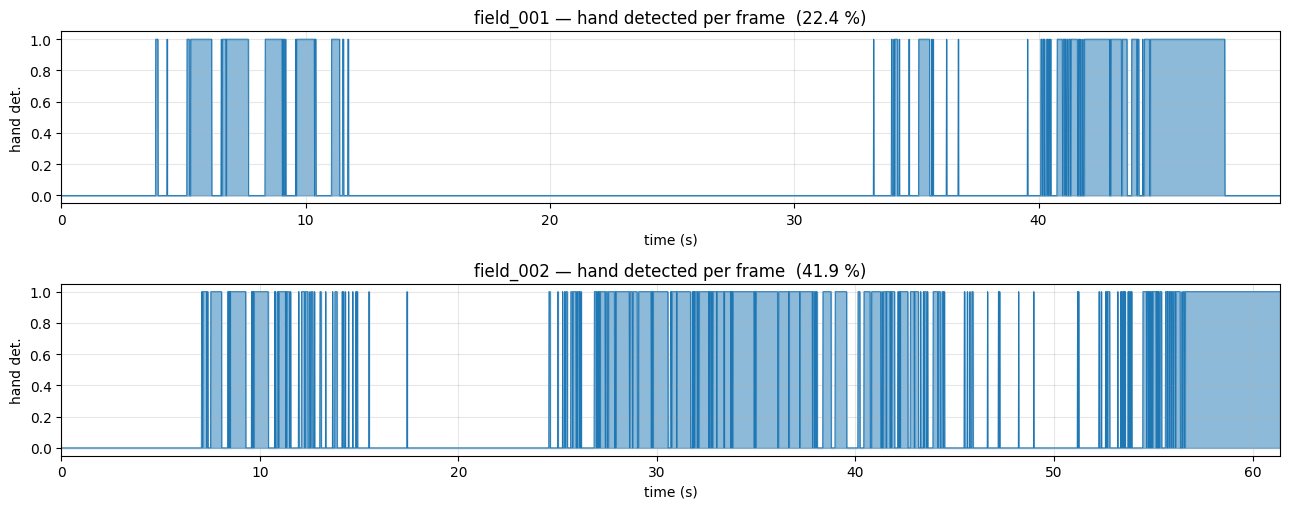

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5.2), sharex=False)
for ax, name in zip(axes, ['field_001', 'field_002']):
    kp = pd.read_csv(VIO / f'{name}_keypoints.csv')
    det_frames = set(kp['frame'].tolist())
    cap = cv2.VideoCapture(str(VIO_RAW[name]))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    t = np.arange(n_frames) / fps
    signal = np.array([1 if f in det_frames else 0 for f in range(n_frames)])

    ax.fill_between(t, 0, signal, step='pre', color='#1f77b4', alpha=0.5)
    ax.plot(t, signal, color='#1f77b4', lw=0.6)
    ax.set_xlim(0, t[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('hand det.')
    ax.set_title(f"{name} — hand detected per frame  ({100*signal.mean():.1f} %)")
    ax.set_xlabel('time (s)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Sample overlay frames — early / mid / late

To get an intuition for *when* hands are detected, here's a 3 × 2 grid: one early, mid and late frame from each clip's overlay video.

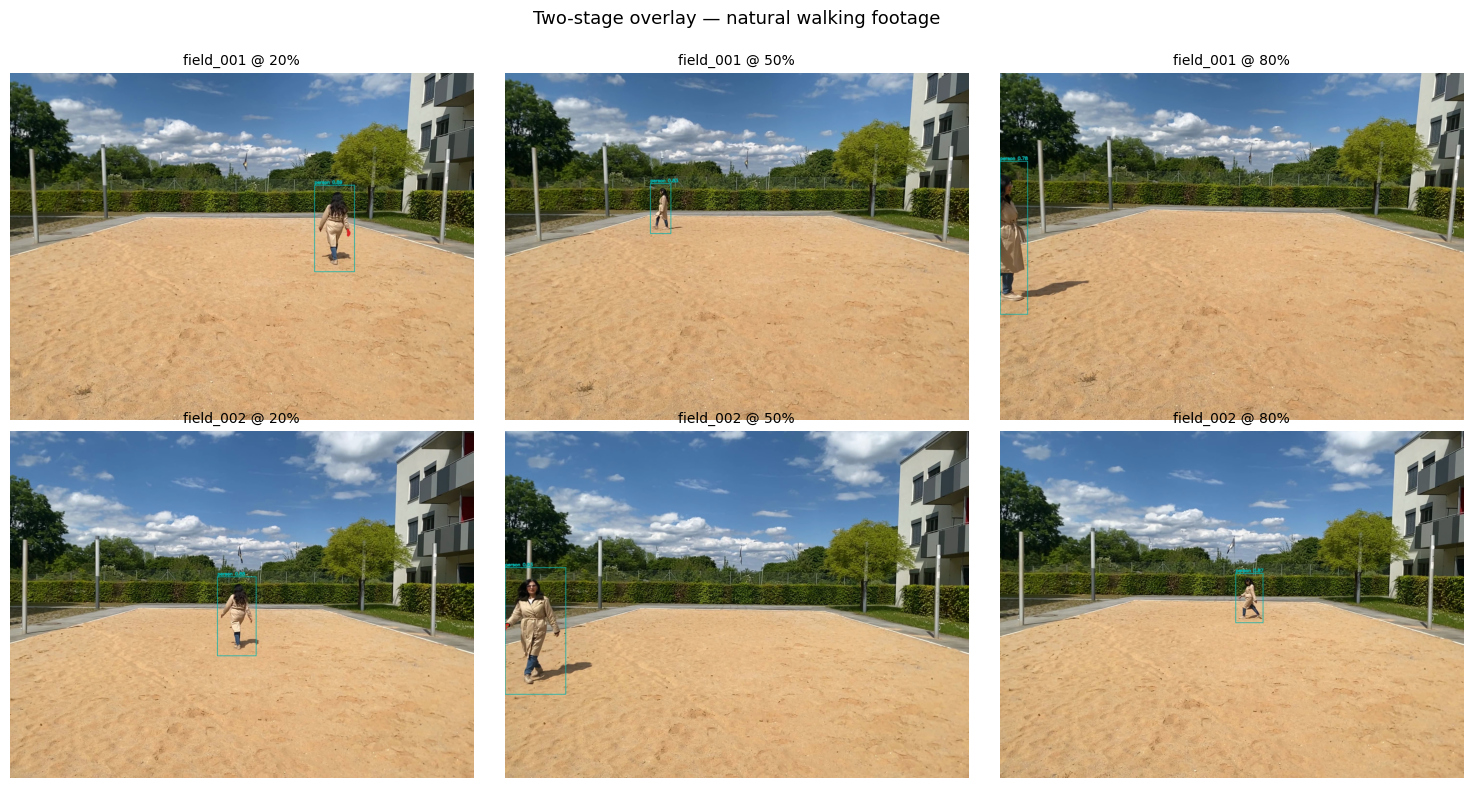

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, name in enumerate(['field_001', 'field_002']):
    overlay = VIO / f'{name}_overlay.mp4'
    if not overlay.exists():
        continue
    cap = cv2.VideoCapture(str(overlay))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for col, frac in enumerate([0.2, 0.5, 0.8]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frac * n))
        ok, fr = cap.read()
        ax = axes[row, col]
        if ok:
            ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name} @ {frac*100:.0f}%", fontsize=10)
        ax.axis('off')
    cap.release()
plt.suptitle('Two-stage overlay — natural walking footage', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Reading the result

* **Hand detection floor in walking video is ~ 22 - 42 %**, *very* different from the 76 - 97 % we got in the gesture clips. This is **not** a detector failure — YOLO finds the person in 84 - 89 % of frames, and the two-stage runner is the same code that gave 97 % at 4 m on the gesture clip.
* The bottleneck is **biological visibility**: while walking, the hand spends a large fraction of each gait cycle either obscured by the body, parallel to the camera (only the edge visible), or fully hidden by the swinging arm motion. There is nothing the detector can do about a frame in which the hand simply isn't there.
* The timeline plot confirms this: detections come in **bursts** (the hand swings forward into the camera's view, then out again). Field 2 has many more bursts because the person walks closer to the camera more often, exposing the palms more.
* For the **gesture classifier**, this means we have two distinct operating regimes:
  1. **Cooperative** (person facing the camera, holding a gesture) — 80 - 97 % usable frames, classifier sees something every frame.
  2. **Incidental** (person walking past the camera) — 20 - 40 % usable frames, classifier needs to be tolerant of long gaps and very short bursts.

This points to a temporal architecture (CNN / Transformer over a 1 - 2 s window) that explicitly handles "no hand visible this frame", rather than a static per-frame classifier.

## 8. Decision for Phase 2 (the gesture classifier)

* **Use the two-stage runner as the canonical input pipeline** for the gesture classifier. It removes the distance bottleneck entirely up to 4 m.
* **Keep the legacy MediaPipe runner as a fast smoke-check** for new clips (no YOLO call → ~ 4 × faster than two-stage).
* **Drop the Tasks API runner** from the pipeline unless we re-tune its presence threshold. The legacy API is fine for the baseline.
* **All keypoint CSVs use the same schema**, so the classifier code does not need to know which detector produced them.

### What the classifier notebook will need next

1. A small `data/gesture/labels.csv` (manually annotated gesture intervals — see §7 of `04_mediapipe_sanity.ipynb`).
2. A `gesture/dataset.py` that loads the keypoint CSVs, applies wrist-centred + MCP9-scaled normalisation, and yields fixed-length windows for training.
3. Baselines:
   * MLP on a single 63-dim normalised frame.
   * 1-D temporal CNN / small Transformer on a 30-frame (1 s) window.
   * Optional crop-then-classify head on the same bbox the two-stage runner already exposes.

The next notebook in this series (`06_gesture_classifier_baseline.ipynb`, TODO) will start from these CSVs and the per-distance split.